In [8]:
# ============================================================
# ZELLE 1: Imports & Konfiguration
# ============================================================
import os
import ast
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm.notebook import tqdm  # tqdm für Jupyter-Fortschrittsbalken

warnings.filterwarnings('ignore')

# --- Reproduzierbarkeit ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ============================================================
# KONFIGURATION – Hier kannst du alles anpassen
# ============================================================
BASE_DIR   = '/datasets/multi-view-pig-posture-recognition'  # <-- Datenpfad
IMG_SIZE   = 224       # Eingabegröße für ResNet-50
BATCH_SIZE = 64        # Batch-Größe
EPOCHS     = 20        # Anzahl Trainings-Epochen
LR         = 3e-4      # Lernrate für den Classifier-Kopf
LR_BACKBONE = 3e-5     # Lernrate für das Backbone (10x kleiner)
NUM_CLASSES = 5        # Anzahl Klassen
NUM_WORKERS = 10        # DataLoader Worker
TARGET_ACC  = 0.82     # Ziel-Accuracy (82%)

# Klassennamen in der Reihenfolge der class_id (0-4)
CLASS_NAMES = [
    'Lateral_lying_left',   # 0
    'Lateral_lying_right',  # 1
    'Sitting',              # 2
    'Standing',             # 3
    'Sternal_lying'         # 4
]

# Device: GPU wenn verfügbar, sonst CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print(f"\nKonfiguration:")
print(f"   Bildgröße:   {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch-Size:  {BATCH_SIZE}")
print(f"   Epochen:     {EPOCHS}")
print(f"   Lernrate:    {LR} (FC) / {LR_BACKBONE} (Backbone)")
print(f"   Ziel-Acc:    {TARGET_ACC*100:.0f}%")

Device: cuda

Konfiguration:
   Bildgröße:   224x224
   Batch-Size:  64
   Epochen:     20
   Lernrate:    0.0003 (FC) / 3e-05 (Backbone)
   Ziel-Acc:    82%


In [9]:
# ============================================================
# ZELLE 2: Daten laden & vorbereiten
# ============================================================
# CSV-Dateien einlesen (train1 + train2 = vollständiger Datensatz)

train1 = pd.read_csv(os.path.join(BASE_DIR, 'train1.csv'))
train1['img_dir'] = 'train1_images'  # Ordner für Bilder aus train1
print(f"   train1.csv: {len(train1):,} Einträge")

train2 = pd.read_csv(os.path.join(BASE_DIR, 'train2.csv'))
train2['img_dir'] = 'train2_images'  # Ordner für Bilder aus train2
print(f"   train2.csv: {len(train2):,} Einträge")

# Zusammenführen zu einem DataFrame
df = pd.concat([train1, train2], ignore_index=True)
print(f"   Gesamt:     {len(df):,} Einträge")

# --- Bounding Boxen parsen ---
# Die bbox-Spalte enthält [cx, cy, w, h] als String → in Zahlen umwandeln
print("\n📐 Parse Bounding Boxen...")
bbox = df['bbox'].apply(ast.literal_eval)
df['cx'] = bbox.apply(lambda b: b[0])  # Center X
df['cy'] = bbox.apply(lambda b: b[1])  # Center Y
df['bw'] = bbox.apply(lambda b: b[2])  # Breite
df['bh'] = bbox.apply(lambda b: b[3])  # Höhe

# Umrechnung: Center-Format → Ecken-Format (xmin, ymin, xmax, ymax)
df['xmin'] = (df['cx'] - df['bw'] / 2).clip(lower=0)
df['ymin'] = (df['cy'] - df['bh'] / 2).clip(lower=0)
df['xmax'] = df.apply(lambda r: min(r['cx'] + r['bw'] / 2, r['width']), axis=1)
df['ymax'] = df.apply(lambda r: min(r['cy'] + r['bh'] / 2, r['height']), axis=1)

# Crop-Größe berechnen
df['crop_w'] = df['xmax'] - df['xmin']
df['crop_h'] = df['ymax'] - df['ymin']

# Zu kleine Bounding Boxen entfernen (< 20 Pixel) – das sind Artefakte
before = len(df)
df = df[(df['crop_w'] >= 20) & (df['crop_h'] >= 20)].reset_index(drop=True)
print(f"   Gefiltert: {before - len(df)} zu kleine BBoxen entfernt")
print(f"   Verbleibend: {len(df):,} BBox-Crops")

# Vollständiger Bildpfad zusammensetzen
df['img_path'] = df.apply(
    lambda r: os.path.join(BASE_DIR, r['img_dir'], r['image_id']), axis=1)

# --- Klassenverteilung anzeigen ---
print(f"\n Klassenverteilung:")
print("-" * 50)
for c in range(NUM_CLASSES):
    n = (df['class_id'] == c).sum()
    bar = "█" * int(n / len(df) * 50)
    print(f"   {c} {CLASS_NAMES[c]:25s}: {n:5d} ({n/len(df)*100:5.1f}%) {bar}")
print("-" * 50)
print(f"   {'GESAMT':27s}: {len(df):5d}")

   train1.csv: 22,934 Einträge
   train2.csv: 23,450 Einträge
   Gesamt:     46,384 Einträge

📐 Parse Bounding Boxen...
   Gefiltert: 0 zu kleine BBoxen entfernt
   Verbleibend: 46,384 BBox-Crops

 Klassenverteilung:
--------------------------------------------------
   0 Lateral_lying_left       :  6136 ( 13.2%) ██████
   1 Lateral_lying_right      :  6811 ( 14.7%) ███████
   2 Sitting                  :  1375 (  3.0%) █
   3 Standing                 : 19545 ( 42.1%) █████████████████████
   4 Sternal_lying            : 12517 ( 27.0%) █████████████
--------------------------------------------------
   GESAMT                     : 46384


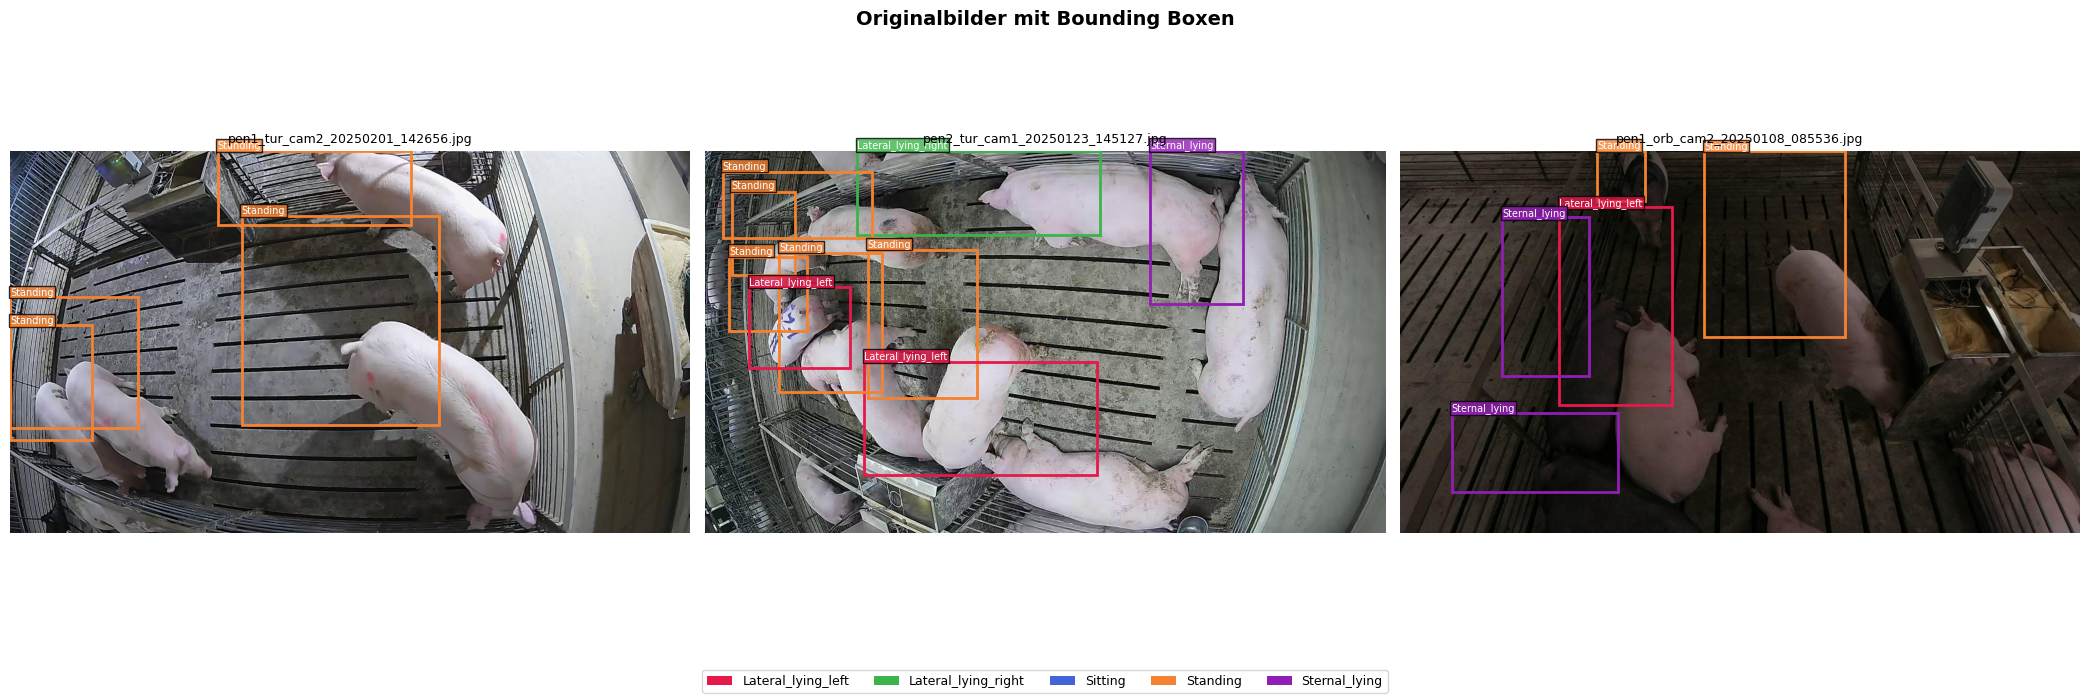

In [10]:
# ============================================================
# ZELLE 3: Visualisierung – Bounding Boxen auf Originalbildern
# ============================================================
COLORS = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']

# Bilder auswählen, die mehrere Schweine zeigen
multi = df.groupby('img_path').filter(lambda x: len(x) >= 3)
imgs = multi['img_path'].unique()
np.random.seed(0)
show_imgs = np.random.choice(imgs, min(3, len(imgs)), replace=False)

fig, axes = plt.subplots(1, len(show_imgs), figsize=(7 * len(show_imgs), 7))
if len(show_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, show_imgs):
    img = Image.open(img_path).convert('RGB')
    ax.imshow(np.array(img))
    
    # Alle BBoxen dieses Bildes einzeichnen
    for _, r in df[df['img_path'] == img_path].iterrows():
        c = int(r['class_id'])
        rect = patches.Rectangle(
            (r['xmin'], r['ymin']), r['crop_w'], r['crop_h'],
            linewidth=2, edgecolor=COLORS[c], facecolor='none')
        ax.add_patch(rect)
        ax.text(r['xmin'], r['ymin'] - 6, CLASS_NAMES[c],
                fontsize=7, color='white',
                bbox=dict(facecolor=COLORS[c], alpha=0.8, pad=1))
    
    ax.set_title(os.path.basename(img_path), fontsize=9)
    ax.axis('off')

# Legende
legend_elements = [patches.Patch(facecolor=COLORS[i], label=CLASS_NAMES[i])
                   for i in range(NUM_CLASSES)]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=NUM_CLASSES, fontsize=9, frameon=True)

plt.suptitle("Originalbilder mit Bounding Boxen", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

In [11]:
# ============================================================
# ZELLE 4: Custom Dataset & DataLoader
# ============================================================

class PigCropDataset(Dataset):
    """
    Custom Dataset: Lädt Bilder und schneidet die Bounding Box aus.
    Jeder Crop wird dann transformiert (Augmentation + Normalisierung).
    """
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Bild laden
        img = Image.open(row['img_path']).convert('RGB')
        
        # Bounding Box ausschneiden (Crop)
        crop = img.crop((
            int(row['xmin']), int(row['ymin']),
            int(row['xmax']), int(row['ymax'])
        ))
        
        # Transformationen anwenden (Augmentation + Normalisierung)
        tensor = self.transform(crop)
        
        # Label
        label = torch.tensor(int(row['class_id']), dtype=torch.long)
        
        return tensor, label


# --- Data Augmentation (Training) ---
# Starke Augmentation verhindert Overfitting und verbessert die Generalisierung
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # Etwas größer resizen...
    transforms.RandomCrop(IMG_SIZE),                     # ...dann zufällig croppen
    transforms.RandomHorizontalFlip(p=0.5),              # Horizontaler Flip
    transforms.RandomVerticalFlip(p=0.1),                # Seltener vertikaler Flip
    transforms.RandomRotation(15),                       # Leichte Rotation (±15°)
    transforms.ColorJitter(                              # Farb-Augmentation
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),                  # Selten in Graustufen
    transforms.ToTensor(),                               # PIL → Tensor [0,1]
    transforms.Normalize(                                # ImageNet-Normalisierung
        mean=[0.485, 0.456, 0.406],                      # (ResNet erwartet das!)
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(p=0.1),                     # Zufällig Bereiche löschen
])

# --- Validation Transform (KEINE Augmentation!) ---
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# --- Train/Val Split (85% Train, 15% Validation) ---
train_df, val_df = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df['class_id']
)

print(f"📊 Datensatz-Split:")
print(f"   Training:   {len(train_df):,} Crops ({len(train_df)/len(df)*100:.0f}%)")
print(f"   Validation: {len(val_df):,} Crops ({len(val_df)/len(df)*100:.0f}%)")

# --- Class Weights berechnen (gegen Klassenungleichgewicht) ---
counts = train_df['class_id'].value_counts().sort_index().values
weights = 1.0 / torch.tensor(counts, dtype=torch.float)
weights = weights / weights.sum() * NUM_CLASSES  # Normalisieren
class_weights = weights.to(device)

print(f"\n⚖️  Class Weights (seltene Klassen bekommen mehr Gewicht):")
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights.cpu())):
    print(f"   {i} {name:25s}: {w:.3f}")

# --- DataLoader erstellen ---
train_loader = DataLoader(
    PigCropDataset(train_df, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,           # Training: Reihenfolge mischen!
    num_workers=NUM_WORKERS,
    pin_memory=True          # Schnellerer GPU-Transfer
)

val_loader = DataLoader(
    PigCropDataset(val_df, val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,           # Validation: NICHT mischen
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"\n✅ DataLoader erstellt:")
print(f"   Train-Batches pro Epoche: {len(train_loader)}")
print(f"   Val-Batches pro Epoche:   {len(val_loader)}")

📊 Datensatz-Split:
   Training:   39,426 Crops (85%)
   Validation: 6,958 Crops (15%)

⚖️  Class Weights (seltene Klassen bekommen mehr Gewicht):
   0 Lateral_lying_left       : 0.698
   1 Lateral_lying_right      : 0.629
   2 Sitting                  : 3.113
   3 Standing                 : 0.219
   4 Sternal_lying            : 0.342

✅ DataLoader erstellt:
   Train-Batches pro Epoche: 617
   Val-Batches pro Epoche:   109


In [12]:
# ============================================================
# ZELLE 5: ResNet-50 mit Transfer Learning
# ============================================================
print("🏗️  Lade vortrainiertes ResNet-50...")

# ResNet-50 mit ImageNet-Gewichten laden
model = models.resnet50(weights='DEFAULT')

# --- Backbone teilweise einfrieren ---
# Untere Schichten (allgemeine Features wie Kanten, Texturen) bleiben fix.
# Obere Schichten (layer3, layer4) werden feingetunt.
frozen_layers = ['conv1', 'bn1', 'layer1', 'layer2']

for name, param in model.named_parameters():
    if any(name.startswith(layer) for layer in frozen_layers):
        param.requires_grad = False  # Einfrieren!

# --- Fully Connected Layer anpassen ---
# Original ResNet-50: fc = Linear(2048, 1000) → 1000 ImageNet-Klassen
# Wir ersetzen das mit unserem eigenen Classifier:
num_features = model.fc.in_features  # = 2048
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),                          # 30% Dropout (Regularisierung)
    nn.Linear(num_features, NUM_CLASSES)          # 2048 → 5 Klassen
)

# Modell auf GPU/CPU verschieben
model = model.to(device)

# --- Optimizer mit unterschiedlichen Lernraten ---
# Backbone (layer3, layer4): Kleine LR → vorsichtig anpassen
# FC-Kopf: Größere LR → schnell lernen
params_backbone = [p for n, p in model.named_parameters()
                   if p.requires_grad and 'fc' not in n]
params_fc = list(model.fc.parameters())

optimizer = optim.AdamW([
    {'params': params_backbone, 'lr': LR_BACKBONE, 'weight_decay': 1e-4},
    {'params': params_fc,       'lr': LR,           'weight_decay': 1e-4},
])

# --- Learning Rate Scheduler ---
# Cosine Annealing: LR sinkt sanft von LR → ~0 über alle Epochen
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# --- Loss-Funktion mit Class Weights ---
criterion = nn.CrossEntropyLoss(weight=class_weights)

# --- Statistiken ---
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\n📊 Modell-Statistiken:")
print(f"   Architektur:      ResNet-50")
print(f"   Parameter gesamt: {total_params:,}")
print(f"   Trainierbar:      {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"   Eingefroren:      {frozen_params:,} ({frozen_params/total_params*100:.1f}%)")
print(f"   Classifier:       Dropout(0.3) → Linear(2048, {NUM_CLASSES})")
print(f"\n   Optimizer:        AdamW")
print(f"   LR Backbone:      {LR_BACKBONE}")
print(f"   LR FC-Kopf:       {LR}")
print(f"   Scheduler:        CosineAnnealing (T_max={EPOCHS})")
print(f"   Loss:             CrossEntropy (gewichtet)")

🏗️  Lade vortrainiertes ResNet-50...


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]


📊 Modell-Statistiken:
   Architektur:      ResNet-50
   Parameter gesamt: 23,518,277
   Trainierbar:      22,073,349 (93.9%)
   Eingefroren:      1,444,928 (6.1%)
   Classifier:       Dropout(0.3) → Linear(2048, 5)

   Optimizer:        AdamW
   LR Backbone:      3e-05
   LR FC-Kopf:       0.0003
   Scheduler:        CosineAnnealing (T_max=20)
   Loss:             CrossEntropy (gewichtet)


In [15]:
# ============================================================
# ZELLE 6: Training mit tqdm-Fortschrittsbalken
# ============================================================
print("🚀 Starte Training...\n")

# Variablen für Logging
best_val_acc = 0.0
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': []
}

# === Epochen-Schleife ===
epoch_bar = tqdm(range(1, EPOCHS + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    # =============================================
    # TRAINING
    # =============================================
    model.train()
    
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    batch_bar = tqdm(
        train_loader,
        desc=f"  Ep {epoch:2d}/{EPOCHS} [Train]",
        leave=False,
        unit="batch"
    )

    for images, labels in batch_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss    += loss.item() * batch_size
        running_correct += (outputs.argmax(dim=1) == labels).sum().item()
        running_total   += batch_size

        current_loss = running_loss / running_total
        current_acc  = running_correct / running_total
        batch_bar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc':  f'{current_acc:.3f}'
        })

    train_loss = running_loss / running_total
    train_acc  = running_correct / running_total

    # =============================================
    # VALIDATION
    # =============================================
    model.eval()
    
    val_loss_sum = 0.0
    val_correct  = 0
    val_total    = 0

    val_bar = tqdm(
        val_loader,
        desc=f"  Ep {epoch:2d}/{EPOCHS} [Val]  ",
        leave=False,
        unit="batch"
    )

    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            val_loss_sum += loss.item() * batch_size
            val_correct  += (outputs.argmax(dim=1) == labels).sum().item()
            val_total    += batch_size

            val_bar.set_postfix({
                'loss': f'{val_loss_sum / val_total:.4f}',
                'acc':  f'{val_correct / val_total:.3f}'
            })

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct / val_total

    scheduler.step()
    current_lr = optimizer.param_groups[1]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Beste Accuracy tracken (nur für Anzeige, kein Speichern)
    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        marker = " ⭐ NEW BEST"
        if val_acc >= TARGET_ACC:
            marker += f" 🎯 ZIEL {TARGET_ACC*100:.0f}% ERREICHT!"

    epoch_bar.set_postfix({
        'train_acc': f'{train_acc:.3f}',
        'val_acc':   f'{val_acc:.3f}',
        'best':      f'{best_val_acc:.3f}',
        'lr':        f'{current_lr:.6f}'
    })

    print(f"  Ep {epoch:2d}/{EPOCHS} │ "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} │ "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f} │ "
          f"LR: {current_lr:.6f}{marker}")

# === Zusammenfassung ===
print(f"\n{'=' * 60}")
print(f"🏆 Training abgeschlossen!")
print(f"   Beste Val Accuracy: {best_val_acc:.4f} ({best_val_acc * 100:.1f}%)")
if best_val_acc >= TARGET_ACC:
    print(f"   ✅ Ziel von {TARGET_ACC*100:.0f}% wurde ERREICHT!")
else:
    print(f"   ⚠️  Ziel von {TARGET_ACC*100:.0f}% wurde nicht erreicht "
          f"(fehlen {(TARGET_ACC - best_val_acc)*100:.1f}%)")
print(f"{'=' * 60}")

🚀 Starte Training...



Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

  Ep  1/20 [Train]:   0%|          | 0/617 [00:00<?, ?batch/s]

  Ep  1/20 [Val]  :   0%|          | 0/109 [00:00<?, ?batch/s]

  Ep  1/20 │ Train Loss: 0.7377  Acc: 0.729 │ Val Loss: 0.6157  Acc: 0.757 │ LR: 0.000293 ⭐ NEW BEST


...

  Ep 19/20 [Val]  :   0%|          | 0/109 [00:00<?, ?batch/s]

  Ep 19/20 │ Train Loss: 0.1663  Acc: 0.931 │ Val Loss: 0.2393  Acc: 0.914 │ LR: 0.000000


  Ep 20/20 [Train]:   0%|          | 0/617 [00:00<?, ?batch/s]

  Ep 20/20 [Val]  :   0%|          | 0/109 [00:00<?, ?batch/s]

  Ep 20/20 │ Train Loss: 0.1665  Acc: 0.930 │ Val Loss: 0.2193  Acc: 0.923 │ LR: 0.000002

🏆 Training abgeschlossen!
   Beste Val Accuracy: 0.9228 (92.3%)
   ✅ Ziel von 82% wurde ERREICHT!


In [16]:
# ============================================================
# ZELLE 10: Modell speichern & Kaggle Submission erstellen
# ============================================================
import ast

# -------------------------------------------------------
# 1) Modell speichern
# -------------------------------------------------------
SAVE_PATH = 'resnet50_pig_posture.pt'
torch.save(model.state_dict(), SAVE_PATH)
print(f"💾 Modell gespeichert: {SAVE_PATH}")
print(f"   Dateigröße: {os.path.getsize(SAVE_PATH) / 1e6:.1f} MB")

# -------------------------------------------------------
# 2) test.csv laden und vorbereiten
# -------------------------------------------------------
print("\n📂 Lade test.csv...")
test_df = pd.read_csv(os.path.join(BASE_DIR, 'test.csv'))
print(f"   Test-Einträge: {len(test_df):,}")

# Bounding Boxen parsen (gleiche Logik wie beim Training)
bbox = test_df['bbox'].apply(ast.literal_eval)
test_df['cx'] = bbox.apply(lambda b: b[0])
test_df['cy'] = bbox.apply(lambda b: b[1])
test_df['bw'] = bbox.apply(lambda b: b[2])
test_df['bh'] = bbox.apply(lambda b: b[3])

test_df['xmin'] = (test_df['cx'] - test_df['bw'] / 2).clip(lower=0)
test_df['ymin'] = (test_df['cy'] - test_df['bh'] / 2).clip(lower=0)
test_df['xmax'] = test_df.apply(lambda r: min(r['cx'] + r['bw'] / 2, r['width']), axis=1)
test_df['ymax'] = test_df.apply(lambda r: min(r['cy'] + r['bh'] / 2, r['height']), axis=1)

# Bildpfade – Test-Bilder liegen im Ordner 'test_images'
test_df['img_path'] = test_df['image_id'].apply(
    lambda x: os.path.join(BASE_DIR, 'test_images', x))

# Prüfen ob Bilder existieren
missing = test_df[~test_df['img_path'].apply(os.path.exists)]
if len(missing) > 0:
    print(f"   ⚠️  {len(missing)} Bilder nicht gefunden!")
    print(f"   Beispiel: {missing.iloc[0]['img_path']}")
else:
    print(f"   ✅ Alle {len(test_df):,} Bilder gefunden")

# -------------------------------------------------------
# 3) Test-Dataset (ohne Labels!)
# -------------------------------------------------------
class PigTestDataset(Dataset):
    """Test-Dataset: Gibt nur Crops zurück, keine Labels."""
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        crop = img.crop((
            int(row['xmin']), int(row['ymin']),
            int(row['xmax']), int(row['ymax'])
        ))
        tensor = self.transform(crop)
        return tensor

test_dataset = PigTestDataset(test_df, val_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # NICHT mischen – Reihenfolge muss erhalten bleiben!
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"   Test-Batches: {len(test_loader)}")

# -------------------------------------------------------
# 4) Vorhersagen generieren
# -------------------------------------------------------
print("\n🔮 Generiere Vorhersagen...")
model.eval()

all_preds = []

with torch.no_grad():
    for images in tqdm(test_loader, desc="Inference", unit="batch"):
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

all_preds = np.array(all_preds)
print(f"   Vorhersagen: {len(all_preds):,}")

# -------------------------------------------------------
# 5) submission.csv erstellen
# -------------------------------------------------------
submission = pd.DataFrame({
    'row_id':   test_df['row_id'],
    'class_id': all_preds.astype(int)
})

# Sicherheits-Check
assert len(submission) == len(test_df), "Anzahl stimmt nicht überein!"
assert submission['class_id'].between(0, 4).all(), "Ungültige Klassen-IDs!"

SUBMISSION_PATH = 'submission.csv'
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"\n📄 Submission gespeichert: {SUBMISSION_PATH}")
print(f"   Zeilen: {len(submission):,}")
print(f"\n   Vorschau:")
print(submission.head(10).to_string(index=False))

# Verteilung der Vorhersagen anzeigen
print(f"\n📊 Verteilung der Vorhersagen:")
print("-" * 45)
for c in range(NUM_CLASSES):
    n = (all_preds == c).sum()
    bar = "█" * int(n / len(all_preds) * 40)
    print(f"   {c} {CLASS_NAMES[c]:25s}: {n:5d} ({n/len(all_preds)*100:5.1f}%) {bar}")

print(f"\n✅ Fertig! Lade '{SUBMISSION_PATH}' bei Kaggle hoch.")

💾 Modell gespeichert: resnet50_pig_posture.pt
   Dateigröße: 94.4 MB

📂 Lade test.csv...
   Test-Einträge: 11,708
   ✅ Alle 11,708 Bilder gefunden
   Test-Batches: 183

🔮 Generiere Vorhersagen...


Inference:   0%|          | 0/183 [00:00<?, ?batch/s]

   Vorhersagen: 11,708

📄 Submission gespeichert: submission.csv
   Zeilen: 11,708

   Vorschau:
                                 row_id  class_id
test_pen1_tur_cam1_20250920_174649_0000         1
test_pen1_tur_cam1_20250920_174649_0001         1
test_pen1_tur_cam1_20250920_174649_0002         4
test_pen1_tur_cam1_20250920_174649_0003         0
test_pen1_tur_cam1_20250920_174649_0004         3
test_pen1_tur_cam1_20250920_174649_0005         4
test_pen1_tur_cam1_20250920_174649_0006         2
test_pen1_tur_cam1_20250920_174649_0007         4
test_pen1_tur_cam1_20250920_174649_0008         0
test_pen1_tur_cam1_20250921_050022_0000         0

📊 Verteilung der Vorhersagen:
---------------------------------------------
   0 Lateral_lying_left       :   999 (  8.5%) ███
   1 Lateral_lying_right      :  1026 (  8.8%) ███
   2 Sitting                  :  1451 ( 12.4%) ████
   3 Standing                 :  6098 ( 52.1%) ████████████████████
   4 Sternal_lying            :  2134 ( 18.2%) ███████

In [ ]:
# 0.278 Kaggle kompetion 